# Comparing Execution Modes: Static, Spiking, and Quasi-Spiking

This notebook provides a direct comparison of three ways to propagate information through a PhasorDense network:

### 1. Static (phase) mode
Input phases are converted to complex unit-circle values via `angle_to_complex`, passed through the weight matrix, then projected back to unit-circle via `normalize_to_unit_circle` (which now includes the −π/2 potential-to-current rotation), and finally converted back to phases. This is a **single, instantaneous** computation with no time dimension.

### 2. Spiking mode
Input phases are encoded as spike times within each period. These drive the ODEs of Resonate-and-Fire oscillators in each layer. The ODE potentials are monitored for threshold crossings; whenever a neuron's imaginary value peaks above threshold, a spike is recorded. The output spike times are decoded back to phases. This is a **sparse, event-driven** computation that runs over multiple oscillation cycles.

### 3. Quasi-spiking mode
Input phases are encoded as spike times (same as spiking mode). But instead of running ODEs, at each time `t` we compute the **complex potential** each input neuron would have at that moment, then pass these complex values directly through the static forward pass of each layer (linear transform + `normalize_to_unit_circle`). This produces a **continuous phase trajectory** that approximates what the spiking oscillators are computing, without the ODE integration overhead.

The key physical insight behind the quasi-spiking mode: when a spiking neuron fires (potential at angle π/2 = `+i`), the spike is received by the next layer as a **positive real current** (`+1`, angle 0). The −π/2 rotation now baked into `normalize_to_unit_circle` ensures that the static layer's output is expressed in the same current convention, enabling direct comparison.

In [1]:
using Pkg
Pkg.activate("..")

  Activating project at `~/code/PhasorNetworks.jl`


In [2]:
using PhasorNetworks
using Lux, LuxCore
using Random: Xoshiro
using Statistics: mean, cor
using Plots
using DifferentialEquations: Tsit5

# Utility: mean ignoring NaN values (NaNStatistics not in project deps)
nanmean(v) = mean(filter(!isnan, v))

nanmean (generic function with 1 method)

## Parameters

In [3]:
seed = 42

# Network architecture
n_in     = 8
n_hidden = 12
n_out    = 4

4

In [4]:
# Oscillation / spiking parameters
repeats  = 6
solver_args = Dict(:adaptive => false, :dt => 0.005, :save_start => true)
spk_args = SpikingArgs(
    t_period  = 1.0f0,
    t_window  = 0.01f0,
    threshold = 0.001f0,
    solver    = Tsit5(),
    solver_args = solver_args
)
tspan = (0.0f0, Float32(repeats) * spk_args.t_period)

println("tspan: ", tspan, "   (", repeats, " cycles × ", spk_args.t_period, " s/cycle)")
println(spk_args)

tspan: (0.0f0, 6.0f0)   (6 cycles × 1.0 s/cycle)
Neuron parameters: Period 1.0 (s)
Current kernel duration: 0.01 (s)
Threshold: 0.001 (V)



## Network Architecture

We build two versions of the same two-layer network, sharing the same learnable weights:

- **Static / quasi-spiking layers** (`l1`, `l2`): standard `PhasorDense` that accepts real phases or complex values.
- **Spiking layers** (`spk_l1`, `spk_l2`): same architecture but configured with `return_type=SolutionType(:spiking)` to accept and produce spike trains via ODE integration.

Both sets of layers are initialised with the same random seed, giving identical initial weights (`ps1`, `ps2`). The spiking layers' state (`spk_st1`, `spk_st2`) is separate from the static state since it tracks leakage/period scaling specific to the ODE solver.

In [5]:
# ── Static / quasi-spiking layers ────────────────────────────────────────────
rng_static = Xoshiro(seed)

l1 = PhasorDense(n_in => n_hidden, normalize_to_unit_circle; use_bias=true)
l2 = PhasorDense(n_hidden => n_out, normalize_to_unit_circle; use_bias=true)

ps1, st1 = Lux.setup(rng_static, l1)
ps2, st2 = Lux.setup(rng_static, l2)

println("Layer 1: ", n_in, " → ", n_hidden,
        "   (weights: ", prod(size(ps1.layer.weight)), ", bias: ", 2*n_hidden, ")")
println("Layer 2: ", n_hidden, " → ", n_out,
        "   (weights: ", prod(size(ps2.layer.weight)), ", bias: ", 2*n_out,   ")")

Layer 1: 8 → 12   (weights: 96, bias: 24)
Layer 2: 12 → 4   (weights: 48, bias: 8)


In [6]:
# ── Spiking layers (same weight structure, same initial weights via same rng state) ──
# Re-seed so the initialisation matches ps1, ps2 exactly.
rng_spk = Xoshiro(seed)

spk_l1 = PhasorDense(n_in => n_hidden, normalize_to_unit_circle;
                     return_type=SolutionType(:spiking), use_bias=true)
spk_l2 = PhasorDense(n_hidden => n_out, normalize_to_unit_circle;
                     return_type=SolutionType(:spiking), use_bias=true)

_, spk_st1 = Lux.setup(rng_spk, spk_l1)   # state only – params come from ps1/ps2
_, spk_st2 = Lux.setup(rng_spk, spk_l2)

println("Spiking layers created (sharing weights ps1, ps2 with static layers)")

Spiking layers created (sharing weights ps1, ps2 with static layers)


## Test Input

We use a single sample (batch size = 1) so individual neuron trajectories are easy to visualise.
The input phases are spread evenly across most of the [-1, 1] range so that all output neurons
receive a range of excitatory and inhibitory drive.

In [7]:
# Single-sample batch: phases spread across [-0.8, 0.8]
x_phases = Float32.(range(-0.8, 0.8, length=n_in))
x = reshape(x_phases, n_in, 1)   # (n_in, batch=1)

println("Input phases: ", round.(x_phases, digits=3))
println("Phase range:  [", minimum(x_phases), ", ", maximum(x_phases), "]")

# Show corresponding spike times within the first period
spike_times_1 = phase_to_time(x, spk_args=spk_args)  # shape: (n_in, 1)
println("Input spike times (first period): ", round.(vec(spike_times_1), digits=3))

Input phases: Float32[-0.8, -0.571, -0.343, -0.114, 0.114, 0.343, 0.571, 0.8]
Phase range:  [-0.8, 0.8]
Input spike times (first period): Float32[0.1, 0.214, 0.329, 0.443, 0.557, 0.671, 0.786, 0.9]


---
## Mode 1 – Static (Phase) Execution

Each layer applies:
1. `angle_to_complex(phases)` — encode phase as a complex unit-circle value  
2. Real-and-imaginary-split linear transform (shared weight matrix `W`)  
3. `normalize_to_unit_circle` — project to unit circle **and rotate by −π/2** (potential → current convention)  
4. `complex_to_angle` — convert back to phase  

This is entirely feedforward with no time dependence.

In [8]:
# ── Static forward pass ──────────────────────────────────────────────────────
y1_static, _ = l1(x, ps1, st1)          # (n_hidden, 1) real phases
y2_static, _ = l2(y1_static, ps2, st2)  # (n_out, 1) real phases

static_phases = vec(y2_static)  # n_out real values
println("Static output phases: ", round.(static_phases, digits=4))

Static output phases: Float32[0.487, 0.2588, -0.2498, -0.0374]


---
## Mode 2 – Spiking (ODE) Execution

1. Input phases → spike train via `phase_to_train` (one spike per neuron per period)  
2. The spike train drives the first layer's Resonate-and-Fire oscillators via ODE integration  
3. Each oscillator fires when its imaginary (voltage) component exceeds the threshold  
4. The resulting output spike train is passed to the second layer  
5. Output spike times are decoded back to phases with `train_to_phase`

The output is a phase per cycle per neuron; we run for `repeats` cycles to observe convergence.

In [9]:
# ── Spiking forward pass ─────────────────────────────────────────────────────
println("Building spike train for ", repeats, " cycles...")
train_in = phase_to_train(x, spk_args=spk_args, repeats=repeats)
println(train_in)

call_in = SpikingCall(train_in, spk_args, tspan)

println("\nRunning spiking layer 1 (ODE integration)...")
out1_spk, _ = spk_l1(call_in, ps1, spk_st1)   # SpikingCall → SpikingCall
println("  Layer 1 output: ", out1_spk.train)

println("\nRunning spiking layer 2 (ODE integration)...")
out2_spk, _ = spk_l2(out1_spk, ps2, spk_st2)   # SpikingCall → SpikingCall
println("  Layer 2 output: ", out2_spk.train)

# Decode spike times → phases, one snapshot per cycle
# Shape: (n_out, batch, n_cycles) with NaN where no spike occurred
phases_spk = train_to_phase(out2_spk)   # (n_out, 1, repeats)
println("\nSpiking output phases (n_out × batch × cycles): ", size(phases_spk))

Building spike train for 6 cycles...
Spike Train: (8, 1) with 48 spikes.

Running spiking layer 1 (ODE integration)...
  Layer 1 output: Spike Train: (12, 1) with 72 spikes.

Running spiking layer 2 (ODE integration)...
  Layer 2 output: Spike Train: (4, 1) with 24 spikes.

Spiking output phases (n_out × batch × cycles): (4, 1, 6)


In [10]:
# Show per-cycle phases for each output neuron (NaN = no spike that cycle)
println("Spiking phases per output neuron per cycle (NaN = silent):")
for i in 1:n_out
    vals = round.(vec(phases_spk[i, 1, :]), digits=4)
    println("  Neuron $i: ", vals)
end

Spiking phases per output neuron per cycle (NaN = silent):
  Neuron 1: Float32[0.0, 0.1553, 0.2898, 0.3755, 0.4269, -0.5511]
  Neuron 2: Float32[0.0, 0.1461, 0.2026, 0.2303, 0.2463, -0.7537]
  Neuron 3: Float32[0.0, -0.1462, -0.1955, -0.2186, -0.2316, 0.745]
  Neuron 4: Float32[0.0, -0.024, -0.0292, -0.0314, -0.0326, 0.9565]


---
## Mode 3 – Quasi-Spiking Execution

Instead of running ODEs, we evaluate the **complex potential** each input neuron would have at each
instant `t`, then immediately propagate it through the static complex forward pass of each layer.

For input neuron `i` that fires at time `t_spike_i` within a period:
$$u_i(t) = e^{\,i\,(\pi/2 - \omega(t - t_{\text{spike},i}))}$$
where `ω = 2π/T`. The potential rotates on the unit circle, passing through `+i` (= angle π/2) exactly at the firing time.

At each `t`, the complex vector `u(t)` is passed through:
1. Layer 1 complex path: `W₁·Re(u) + i·W₁·Im(u)` → `normalize_to_unit_circle` (with −π/2 rotation)  
2. Layer 2 complex path: same on the layer-1 output  
3. `complex_to_angle` → output phase at time `t`

The output is a smooth phase trajectory over time. Where the trajectory passes through phase 0 (positive-real current = neuron "firing"), the spiking mode would detect a spike.

In [14]:
# ── Quasi-spiking forward pass at a single time t ────────────────────────────
function quasi_spiking_at_t(t::Real, spike_times, ps1, st1, ps2, st2)
    # Complex potential of each input neuron at time t
    # shape: (n_in, batch)
    u_in = time_to_potential(spike_times, Float32(t), spk_args=spk_args)

    # Layer 1 complex forward pass (dispatches on AbstractArray{<:Complex})
    # Output: complex unit-circle values (normalized + rotated by −π/2)
    y1_cmpx, _ = l1(u_in, ps1, st1)

    # Layer 2 complex forward pass
    y2_cmpx, _ = l2(y1_cmpx, ps2, st2)

    # Convert complex current to phase
    return complex_to_angle(y2_cmpx .* ComplexF32(0.0f0 + 1.0f0im))  # (n_out, batch) real
end

# Build a dense time grid spanning the full simulation window
n_t_points = 600
ts = Float32.(range(tspan[1], tspan[2], length=n_t_points))

println("Evaluating quasi-spiking across ", n_t_points, " time points...")
quasi_phases_all = stack([quasi_spiking_at_t(t, spike_times_1, ps1, st1, ps2, st2)
                          for t in ts])  # shape: (n_out, batch, n_t_points)

println("Quasi-spiking trajectory shape: ", size(quasi_phases_all))
println("Phase range: [", round(minimum(quasi_phases_all), digits=3),
        ", ", round(maximum(quasi_phases_all), digits=3), "]")

Evaluating quasi-spiking across 600 time points...
Quasi-spiking trajectory shape: (4, 1, 600)
Phase range: [-0.292, 0.717]


---
## Comparison Visualisation

For each output neuron we plot:
- **Blue dashed line**: Static mode output phase (constant in time)
- **Orange circles**: Spiking mode detected phases, one per oscillation cycle (gaps = silent cycles)
- **Red curve**: Quasi-spiking continuous phase trajectory

A phase of **0** in the quasi-spiking mode corresponds to the output current pointing in the
+real direction — the same convention as a spiking neuron's peak current at its firing time.
The spiking-mode dots should cluster near these moments.

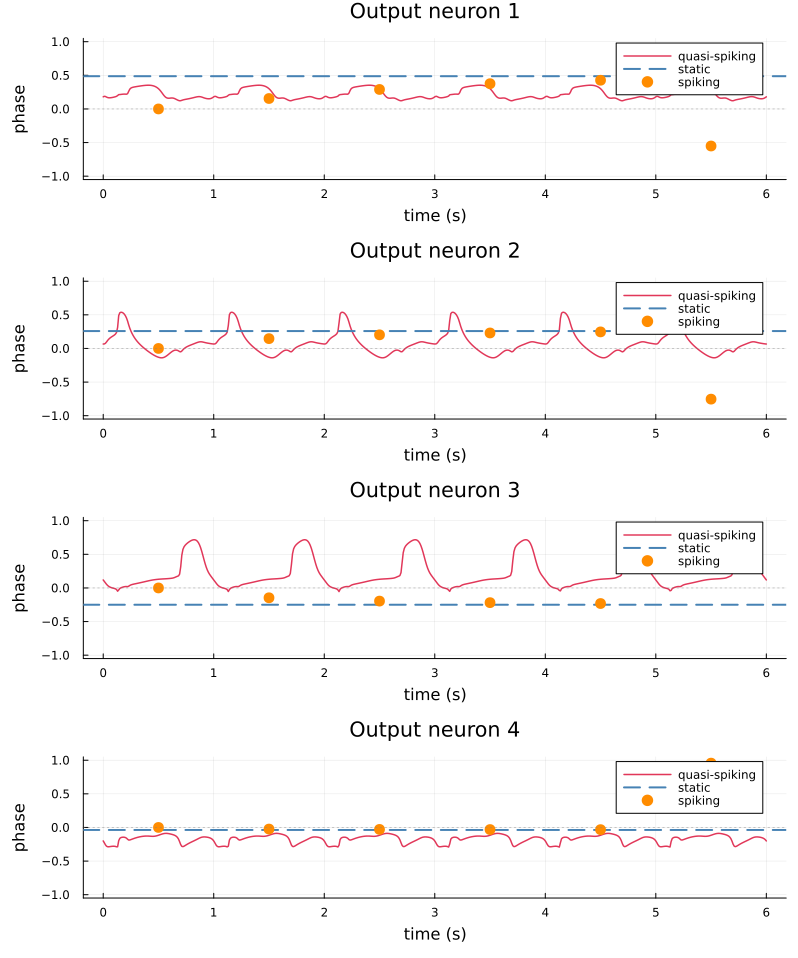

In [15]:
# Spiking cycle centres for scatter plot (mid-point of each cycle)
cycle_times = [(k - 0.5f0) * spk_args.t_period for k in 1:size(phases_spk, 3)]

plts = []
for i in 1:n_out
    spk_y = vec(phases_spk[i, 1, :])   # one value per cycle, NaN if silent
    qs_y  = vec(quasi_phases_all[i, 1, :])  # one value per time point

    p = plot(
        ts, qs_y;
        label="quasi-spiking", color=:crimson, lw=1.5, alpha=0.85,
        xlabel="time (s)", ylabel="phase",
        title="Output neuron $i",
        ylims=(-1.05, 1.05), legend=:topright,
        size=(700, 230)
    )

    # Static output – horizontal line
    hline!(p, [static_phases[i]];
           label="static", color=:steelblue, lw=2, ls=:dash)

    # Spiking phases – scatter, skip NaN
    valid = .!isnan.(spk_y)
    if any(valid)
        scatter!(p, cycle_times[valid], spk_y[valid];
                 label="spiking", color=:darkorange, ms=6, msw=0)
    end

    # Mark phase = 0 with a thin grey line (firing-equivalent current direction)
    hline!(p, [0.0]; label="", color=:grey, lw=0.8, ls=:dot, alpha=0.5)

    push!(plts, p)
end

plot(plts...; layout=(n_out, 1), size=(800, 240*n_out), left_margin=5Plots.mm)

### Complex-plane portrait of the quasi-spiking trajectory

Each output neuron's complex current over time traces a closed path on (or near) the unit circle.
The trajectory rotates at the oscillator frequency. When it passes through `+1` (angle 0, right side),
the neuron is producing maximum excitatory current — the continuous analogue of a spike.

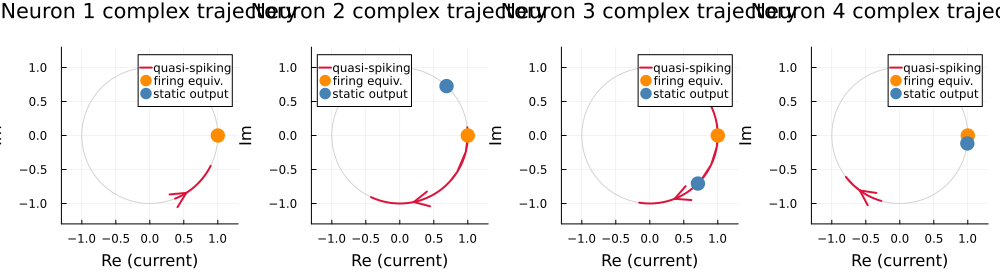

In [13]:
# Re-run to collect complex outputs (not just phases)
function quasi_spiking_complex_at_t(t::Real, spike_times, ps1, st1, ps2, st2)
    u_in = time_to_potential(spike_times, Float32(t), spk_args=spk_args)
    y1_cmpx, _ = l1(u_in, ps1, st1)
    y2_cmpx, _ = l2(y1_cmpx, ps2, st2)
    return y2_cmpx  # complex, shape (n_out, batch)
end

# Evaluate over one period (the pattern repeats every period)
ts_one_period = Float32.(range(0, spk_args.t_period, length=200))
cmpx_one_period = stack([quasi_spiking_complex_at_t(t, spike_times_1, ps1, st1, ps2, st2)
                         for t in ts_one_period])  # (n_out, 1, 200)

portrait_plts = []
θ = range(0, 2π, length=100)  # unit circle reference
for i in 1:n_out
    zs = vec(cmpx_one_period[i, 1, :])  # complex trajectory over one period

    # Firing-equivalent point: +1 (angle 0)
    p = plot(cos.(θ), sin.(θ);
             color=:lightgrey, lw=1, label="",
             aspect_ratio=1, xlims=(-1.3, 1.3), ylims=(-1.3, 1.3),
             title="Neuron $i complex trajectory",
             xlabel="Re (current)", ylabel="Im")

    plot!(p, real.(zs), imag.(zs);
          label="quasi-spiking", color=:crimson, lw=2, arrow=true)

    # Mark the firing-equivalent direction (+1 = max excitatory current)
    scatter!(p, [1.0], [0.0]; label="firing equiv.", color=:darkorange, ms=8, msw=0)
    # Mark static output direction
    scatter!(p, [cos(π * static_phases[i])], [sin(π * static_phases[i])];
             label="static output", color=:steelblue, ms=8, msw=0)

    push!(portrait_plts, p)
end

plot(portrait_plts...; layout=(1, n_out), size=(250*n_out, 280))

---
## Quantitative Comparison

### 1. Static vs. spiking correlation
Compare the static output phases with the final few cycles of the spiking output
(the spiking network needs a few cycles to settle from the initial transient).

### 2. Quasi-spiking time-average vs. static
The time-average of the quasi-spiking trajectory (mean phase over one period) should
approximate the static output, since the linear layer is linear and the mean potential
over a period reflects the dominant drive.

### 3. Quasi-spiking zero-crossing vs. spiking phases
The time at which the quasi-spiking phase is nearest to 0 (max excitatory current direction)
should roughly align with the spiking-mode detected phase within each cycle.

In [16]:
# ── 1. Static vs. spiking correlation ────────────────────────────────────────
# Use the last half of cycles (after transient) and average over them
n_steady = max(1, repeats ÷ 2)  # number of steady-state cycles
spk_steady = phases_spk[:, 1, end-n_steady+1:end]  # (n_out, n_steady)

# nanmean over cycles
spk_mean = [nanmean(spk_steady[i, :]) for i in 1:n_out]

println("Static output phases:         ", round.(static_phases, digits=4))
println("Spiking mean (steady cycles): ", round.(spk_mean, digits=4))

# Correlation (ignore NaN)
valid = .!isnan.(spk_mean)
if sum(valid) >= 2
    c = cor(static_phases[valid], spk_mean[valid])
    println("\nCorrelation (static vs spiking mean): ", round(c, digits=4))
else
    println("\nNot enough non-NaN spiking values for correlation (need more repeats or lower threshold)")
end

Static output phases:         Float32[0.487, 0.2588, -0.2498, -0.0374]
Spiking mean (steady cycles): Float32[0.0838, -0.0924, 0.0983, 0.2975]

Correlation (static vs spiking mean): -0.4073


Static output phases:         Float32[0.487, 0.2588, -0.2498, -0.0374]
Quasi-spiking time mean:      Float32[0.2189, 0.0797, 0.2117, -0.1726]

Correlation (static vs quasi-spiking mean): 0.2366


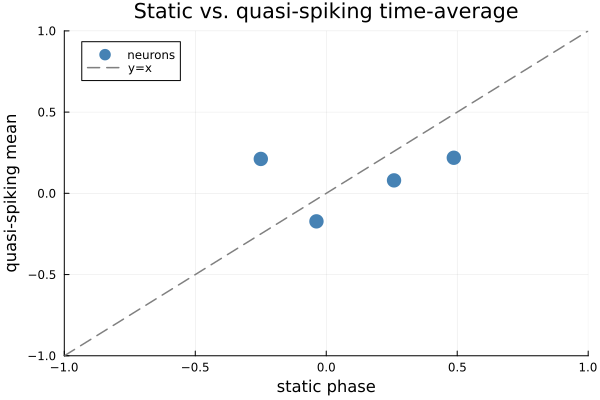

In [17]:
# ── 2. Quasi-spiking time-average vs. static ─────────────────────────────────
# Average the quasi-spiking trajectory over one period (the last full period)
last_period_mask = ts .>= (tspan[2] - spk_args.t_period)
qs_last_period = quasi_phases_all[:, 1, last_period_mask]  # (n_out, n_points_in_last_period)
qs_mean = vec(mean(qs_last_period, dims=2))  # (n_out,)

println("Static output phases:         ", round.(static_phases, digits=4))
println("Quasi-spiking time mean:      ", round.(qs_mean, digits=4))

c_qs = cor(static_phases, qs_mean)
println("\nCorrelation (static vs quasi-spiking mean): ", round(c_qs, digits=4))

scatter(static_phases, qs_mean;
        label="neurons", xlabel="static phase", ylabel="quasi-spiking mean",
        title="Static vs. quasi-spiking time-average",
        ms=8, msw=0, color=:steelblue)
plot!(x -> x; label="y=x", color=:grey, ls=:dash, lw=1.5, xlims=(-1,1), ylims=(-1,1))

In [18]:
# ── 3. Quasi-spiking zero-crossing time vs. spiking detected phase ────────────
# For each output neuron, find the time within each cycle where quasi-spiking
# phase is closest to 0 (= current pointing right = firing-equivalent event)
function find_zero_crossing_phase(quasi_traj, ts, t_period)
    # Returns the decoded spiking-convention phase of the quasi-spiking
    # zero-crossing (phase closest to 0) within each oscillation period.
    n_cycles = round(Int, (ts[end] - ts[1]) / t_period)
    crossing_phases = fill(NaN32, n_cycles)
    for k in 1:n_cycles
        t_start = (k-1) * t_period
        t_end   = k * t_period
        mask = (ts .>= t_start) .& (ts .< t_end)
        if any(mask)
            segment = quasi_traj[mask]
            idx_min = argmin(abs.(segment))
            t_cross = ts[mask][idx_min]
            # time_to_phase requires an array; wrap and unwrap
            crossing_phases[k] = time_to_phase([t_cross], t_period, 0.0f0)[1]
        end
    end
    return crossing_phases
end

println("Comparing spiking detected phases vs quasi-spiking zero-crossing phases:")
println()
for i in 1:n_out
    qs_traj_i = vec(quasi_phases_all[i, 1, :])
    zc_phases = find_zero_crossing_phase(qs_traj_i, ts, spk_args.t_period)
    spk_phases_i = vec(phases_spk[i, 1, :])

    println("Neuron $i:")
    println("  Spiking phases per cycle:       ", round.(spk_phases_i, digits=3))
    println("  Quasi zero-crossing phases:     ", round.(zc_phases, digits=3))

    valid_both = .!isnan.(spk_phases_i) .& .!isnan.(zc_phases)
    if sum(valid_both) >= 2
        c = cor(spk_phases_i[valid_both], zc_phases[valid_both])
        println("  Correlation (spiking vs quasi zero-crossing): ", round(c, digits=4))
    end
    println()
end

Comparing spiking detected phases vs quasi-spiking zero-crossing phases:

Neuron 1:
  Spiking phases per cycle:       Float32[0.0, 0.155, 0.29, 0.376, 0.427, -0.551]
  Quasi zero-crossing phases:     Float32[0.382, 0.386, 0.389, 0.392, 0.396, 0.399]
  Correlation (spiking vs quasi zero-crossing): -0.2741

Neuron 2:
  Spiking phases per cycle:       Float32[0.0, 0.146, 0.203, 0.23, 0.246, -0.754]
  Quasi zero-crossing phases:     Float32[-0.259, -0.255, 0.469, 0.472, 0.476, -0.262]
  Correlation (spiking vs quasi zero-crossing): 0.6134

Neuron 3:
  Spiking phases per cycle:       Float32[0.0, -0.146, -0.195, -0.219, -0.232, 0.745]
  Quasi zero-crossing phases:     Float32[-0.84, -0.836, -0.833, -0.83, -0.686, -0.683]
  Correlation (spiking vs quasi zero-crossing): 0.5441

Neuron 4:
  Spiking phases per cycle:       Float32[0.0, -0.024, -0.029, -0.031, -0.033, 0.957]
  Quasi zero-crossing phases:     Float32[0.142, 0.145, 0.129, 0.132, 0.135, 0.139]
  Correlation (spiking vs quasi zero-c

### Overlay: quasi-spiking zero-crossings on the trajectory plot

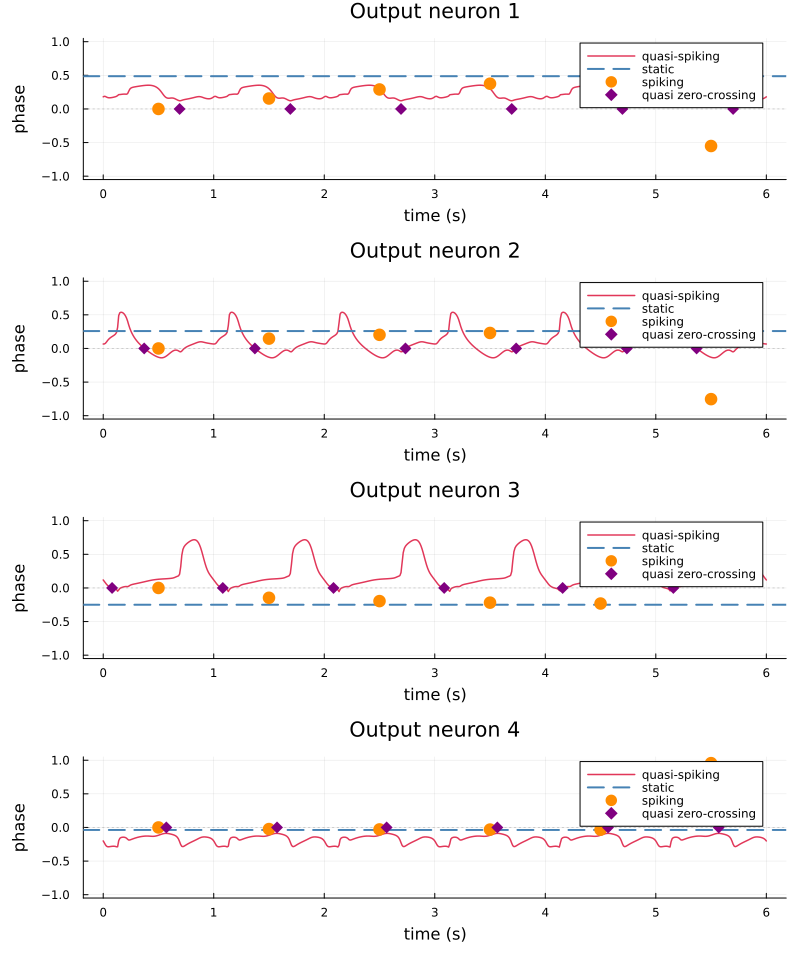

In [19]:
plts2 = []
for i in 1:n_out
    qs_traj_i  = vec(quasi_phases_all[i, 1, :])
    spk_y      = vec(phases_spk[i, 1, :])
    zc_phases  = find_zero_crossing_phase(qs_traj_i, ts, spk_args.t_period)

    p = plot(ts, qs_traj_i;
             label="quasi-spiking", color=:crimson, lw=1.5, alpha=0.85,
             xlabel="time (s)", ylabel="phase",
             title="Output neuron $i",
             ylims=(-1.05, 1.05), legend=:topright)

    hline!(p, [static_phases[i]]; label="static", color=:steelblue, lw=2, ls=:dash)
    hline!(p, [0.0]; label="", color=:grey, lw=0.8, ls=:dot, alpha=0.4)

    # Spiking detections
    valid_spk = .!isnan.(spk_y)
    if any(valid_spk)
        scatter!(p, cycle_times[valid_spk], spk_y[valid_spk];
                 label="spiking", color=:darkorange, ms=7, msw=0)
    end

    # Quasi zero-crossings (times within each cycle closest to phase 0)
    valid_zc = .!isnan.(zc_phases)
    if any(valid_zc)
        # Find the time of zero-crossing in each cycle
        zc_times = Float32[]
        for k in 1:repeats
            if valid_zc[k]
                t_start = (k-1) * spk_args.t_period
                t_end   = k * spk_args.t_period
                mask = (ts .>= t_start) .& (ts .< t_end)
                seg  = qs_traj_i[mask]
                idx  = argmin(abs.(seg))
                push!(zc_times, ts[mask][idx])
            end
        end
        scatter!(p, zc_times, zeros(length(zc_times));
                 label="quasi zero-crossing", color=:purple, ms=6, shape=:diamond, msw=0)
    end

    push!(plts2, p)
end

plot(plts2...; layout=(n_out, 1), size=(800, 240*n_out), left_margin=5Plots.mm)

---
## Summary and Interpretation

### What we observe

| Mode | Time-dependence | Sparsity | Output |
|------|----------------|----------|--------|
| Static | None | All neurons always active | Single phase per neuron |
| Spiking | Full ODE dynamics | Threshold-gated | Phase per cycle (NaN = silent) |
| Quasi-spiking | Continuous trajectory | Magnitude-weighted | Smooth phase curve |

### The role of the −π/2 rotation

After the rotation added to `normalize_to_unit_circle`:
- A neuron with potential at angle **π/2** (`+i`, about to fire) produces output current at angle **0** (`+1`, max excitatory).
- The quasi-spiking phase trajectory passes through **0** at the moment corresponding to the spiking model's firing event.
- The **purple diamonds** (quasi zero-crossings) should cluster near the **orange dots** (spiking detections) within each cycle.

### Approximation gaps that remain

The quasi-spiking mode cannot fully replace the spiking model because:

1. **No temporal integration**: The spiking ODEs accumulate current over a full cycle; the quasi-spiking snapshots at each instant. Resonant frequency selectivity and leakage are absent.
2. **No threshold**: All neurons contribute in the quasi-spiking mode; only above-threshold neurons fire in the spiking model. The `soft_normalize_to_unit_circle` partially models this via magnitude-dependent contribution strength.
3. **No causal ordering**: Spiking networks have causal delay (spikes propagate at finite time); the quasi-spiking mode is instantaneous.

The quasi-spiking mode is best understood as a **differentiable, trainable approximation** to the spiking network that:
- Shares the same weight matrices
- Respects the same firing-time convention (via the −π/2 rotation)
- Is fully differentiable through Zygote, enabling gradient-based learning
- Can be evaluated in a single forward pass per time point (no ODE solver needed)